In [1]:
# NOTE THAT THIS IS CURRENTLY IMPLEMENTED ONLY FOR THE MNN MAPPING
here::i_am("rna/mapping/run/parse_sample_metadata_after_mapping.R")
suppressPackageStartupMessages(library(argparse))



here() starts at /rds/project/rds-SDzz0CATGms/users/bt392/10_Eomes_invitro_gut/code



In [3]:
######################
## Define arguments ##
######################

# p <- ArgumentParser(description='')
# p$add_argument('--query_metadata',        type="character",                               help='Cell metadata (after mapping)')
# p$add_argument('--samples',         type="character",       nargs="+",   help='Samples')
# p$add_argument('--atlas_metadata',        type="character",                               help='Cell metadata (after mapping)')
# p$add_argument('--outdir',          type="character",                               help='Output file')

# args <- p$parse_args(commandArgs(TRUE))

## START TEST ##
args = list()
 args$query_metadata <- "/rds/project/rds-SDzz0CATGms/users/bt392/10_Eomes_invitro_gut/results/rna/mapping/sample_metadata_after_mapping.txt.gz"
 args$atlas_metadata <- "/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/gastrulation/pijuansala2019_gastrulation10x/sample_metadata.txt.gz"
args$samples = c('RBG43471','RBG43472','RBG43473','RBG43474','RBG43475','RBG43476','RBG43477','RBG43478')
# args$outdir <- "/Users/argelagr/data/gastrulation_histones/results/rna/mapping/pdf"
## END TEST ##

#####################
## Define settings ##
#####################

# load default setings
source(here::here("settings.R"))

# Options

# Dot size
opts$size.mapped <- 0.18
opts$size.nomapped <- 0.1

# Transparency
opts$alpha.mapped <- 0.65
opts$alpha.nomapped <- 0.35

###################
## Load metadata ##
###################

sample_metadata <- fread(args$query_metadata) %>%
  .[pass_rnaQC==TRUE & sample%in%args$samples & !is.na(closest.cell)]

stopifnot("closest.cell"%in%colnames(sample_metadata))

####################
## Load 10x atlas ##
####################

# Load atlas cell metadata
meta_atlas <- fread(args$atlas_metadata) %>%
  # .[celltype%in%opts$celltypes] %>%
  .[stripped==F & doublet==F]

# Extract precomputed dimensionality reduction coordinates
umap.dt <- meta_atlas %>%
  .[,c("cell","umapX","umapY","celltype")] %>%
  setnames(c("umapX","umapY"),c("V1","V2"))

##############################
## Define plotting function ##
##############################


plot.dimred <- function(plot_df, query.label, atlas.label = "Atlas") {
  
  # Define dot size  
  size.values <- c(opts$size.mapped, opts$size.nomapped)
  names(size.values) <- c(query.label, atlas.label)
  
  # Define dot alpha  
  alpha.values <- c(opts$alpha.mapped, opts$alpha.nomapped)
  names(alpha.values) <- c(query.label, atlas.label)
  
  # Define dot colours  
  colour.values <- c("red", "lightgrey")
  names(colour.values) <- c(query.label, atlas.label)
  
  # Plot
  ggplot(plot_df, aes(x=V1, y=V2)) +
    ggrastr::geom_point_rast(aes(size=mapped, alpha=mapped, colour=mapped)) +
    scale_size_manual(values = size.values) +
    scale_alpha_manual(values = alpha.values) +
    scale_colour_manual(values = colour.values) +
    # labs(x="UMAP Dimension 1", y="UMAP Dimension 2") +
    guides(colour = guide_legend(override.aes = list(size=6))) +
    theme_classic() +
    theme(
      legend.position = "top", 
      legend.title = element_blank(),
      axis.line = element_blank(),
      axis.text = element_blank(),
      axis.title = element_blank(),
      axis.ticks = element_blank()
    )
}



In [8]:
head(umap.dt)

cell,V1,V2,celltype
<chr>,<dbl>,<dbl>,<chr>
cell_1,-10.2275459,-2.8816875,Epiblast
cell_10,-11.2435319,-0.8761099,Epiblast
cell_100,-10.9044295,-0.9639773,Epiblast
cell_1000,-2.9437001,-0.7820226,Caudal_epiblast
cell_10000,-7.3668170,-2.2819553,Rostral_neurectoderm
cell_100000,-0.9185215,-5.5175930,Forebrain_Midbrain_Hindbrain


In [6]:
to.plot <- umap.dt %>% copy %>%
  .[,index:=match(cell, sample_metadata[,closest.cell] )] %>% 
  .[,mapped:=as.factor(!is.na(index))] %>% 
  .[,mapped:=plyr::mapvalues(mapped, from = c("FALSE","TRUE"), to = c("scRNA-seq atlas","Experiment"))] %>%
  setorder(mapped) 

In [ ]:
plot.dimred(to.plot, query.label = "Experiment", atlas.label = "scRNA-seq atlas") +
    facet_grid(~genotype) + 

In [12]:
query_full = sample_metadata %>%
                    merge(umap.dt[,c('cell', 'V1', 'V2')], by.x='closest.cell', by.y='cell') %>% # add FA of closest cells
                    setnames('day', 'Day')  

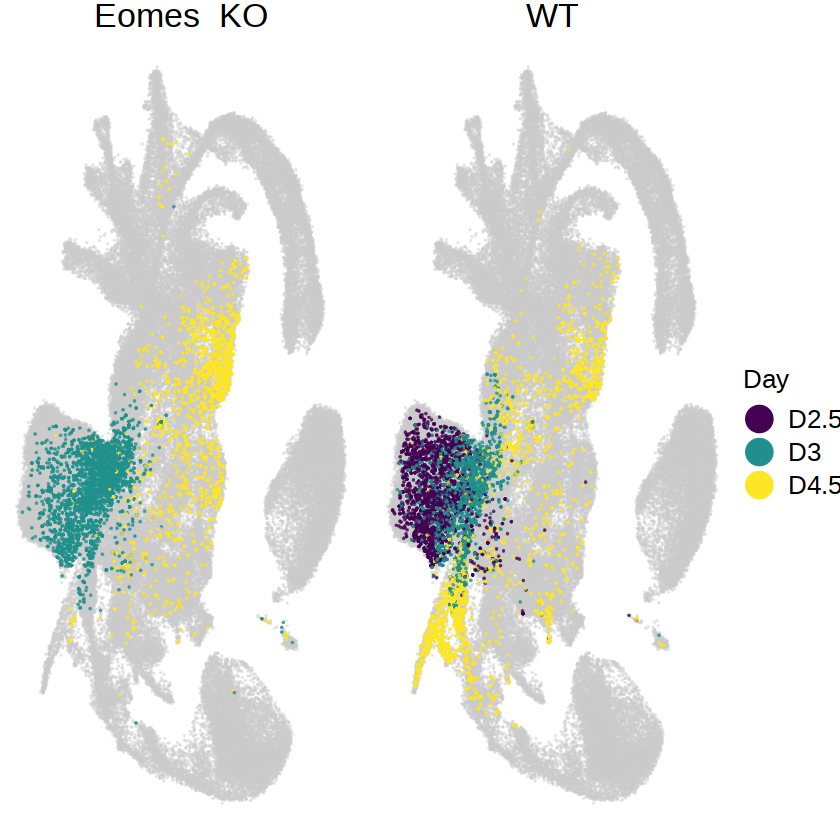

In [23]:
ggplot(query_full, aes(V1, V2, col = Day)) + 
        ggrastr::geom_point_rast(data=umap.dt, 
                                      aes(V1, V2),
                                      size=opts$size.nomapped,
                                      alpha=opts$alpha.nomapped,
                                      col='gray80') + 
        ggrastr::geom_point_rast(alpha=opts$alpha.mapped, size = opts$size.mapped) +
        viridis::scale_color_viridis(discrete=TRUE) + 
        guides(colour = guide_legend(override.aes = list(size=7, alpha=1))) +
        facet_grid(~genotype) + 
        theme_void() + 
        theme(strip.text.x = element_text(size = 20),
              legend.title = element_text(size=15),
              legend.text = element_text(size=15))

In [ ]:
pdf(sprintf("%s/umap_mapped_allcells.pdf",args$outdir), width=8, height=6.5)
 print(p)
dev.off()

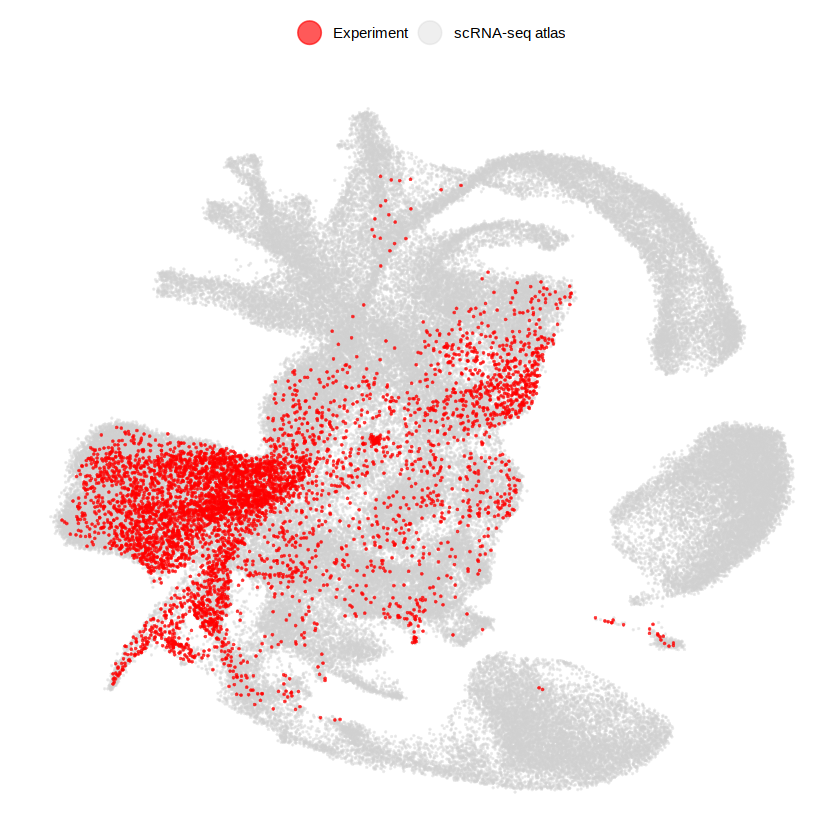

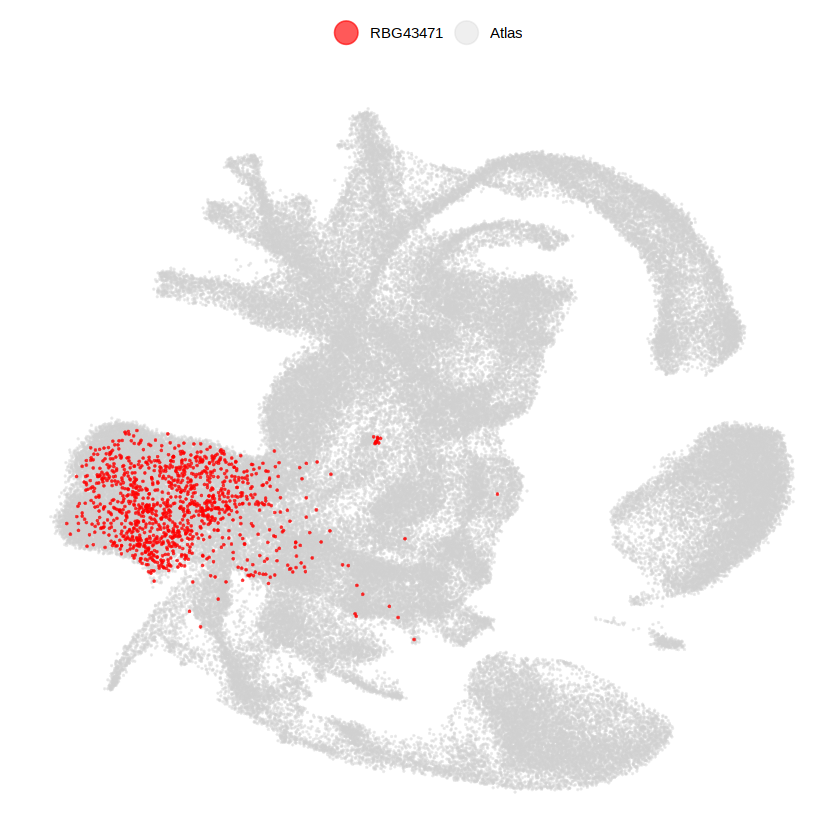

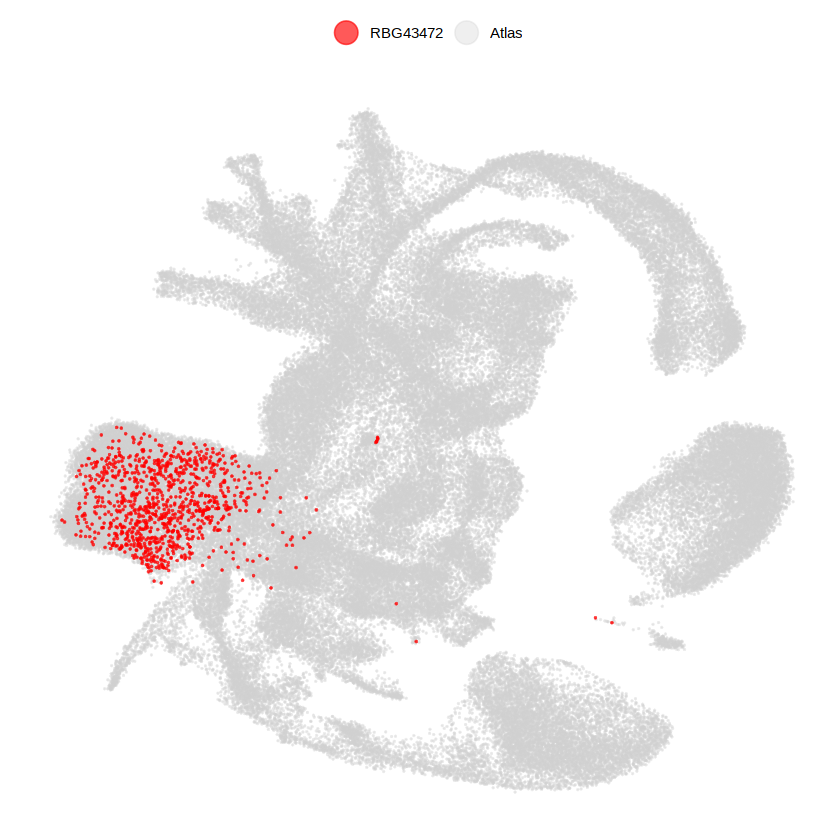

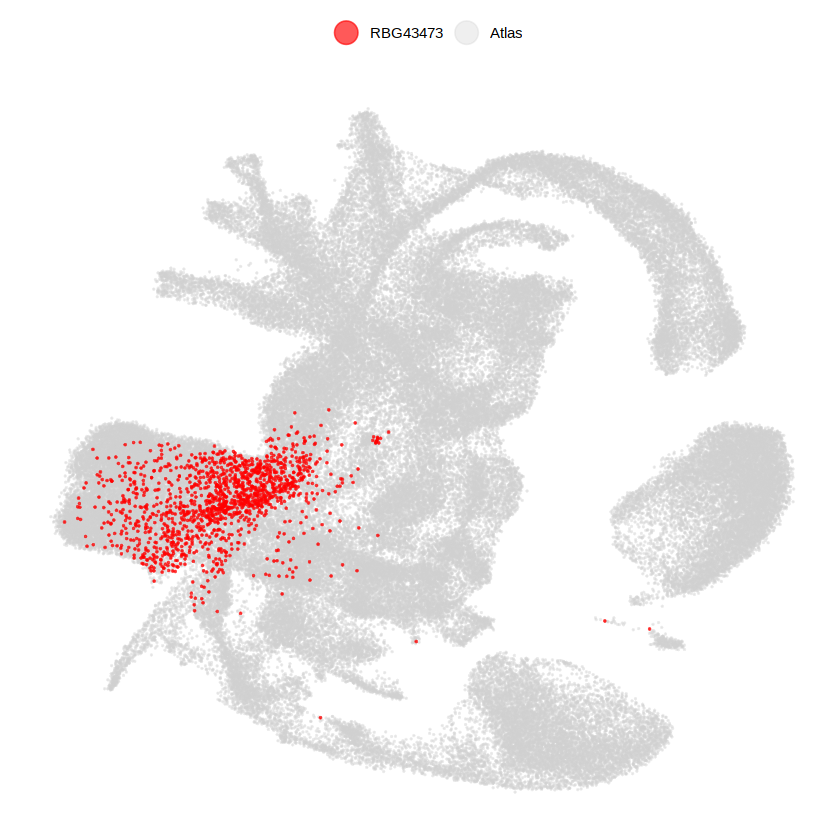

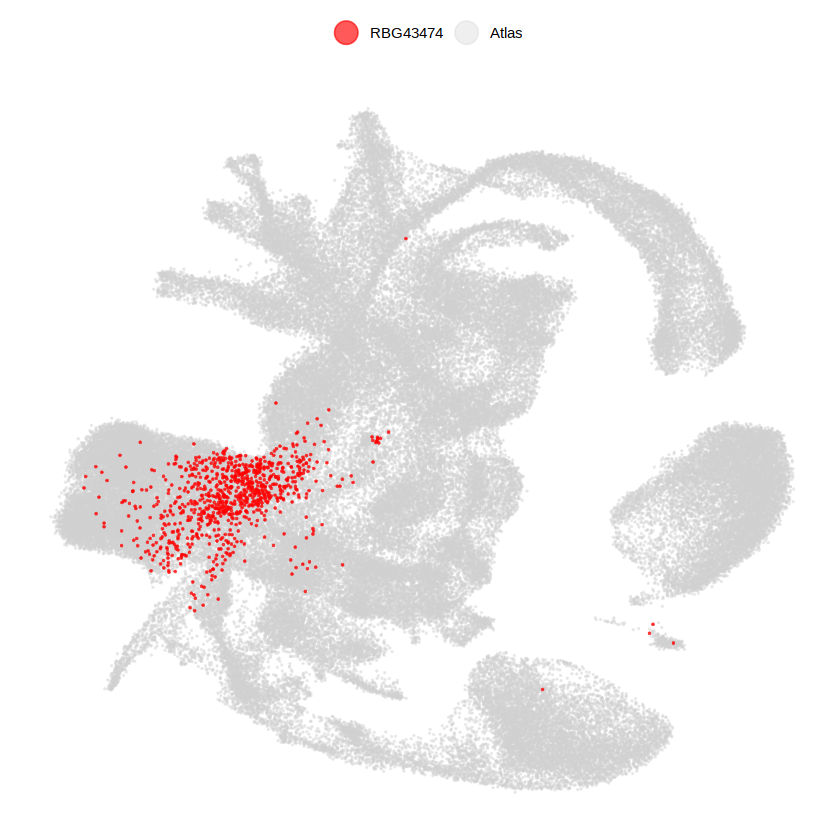

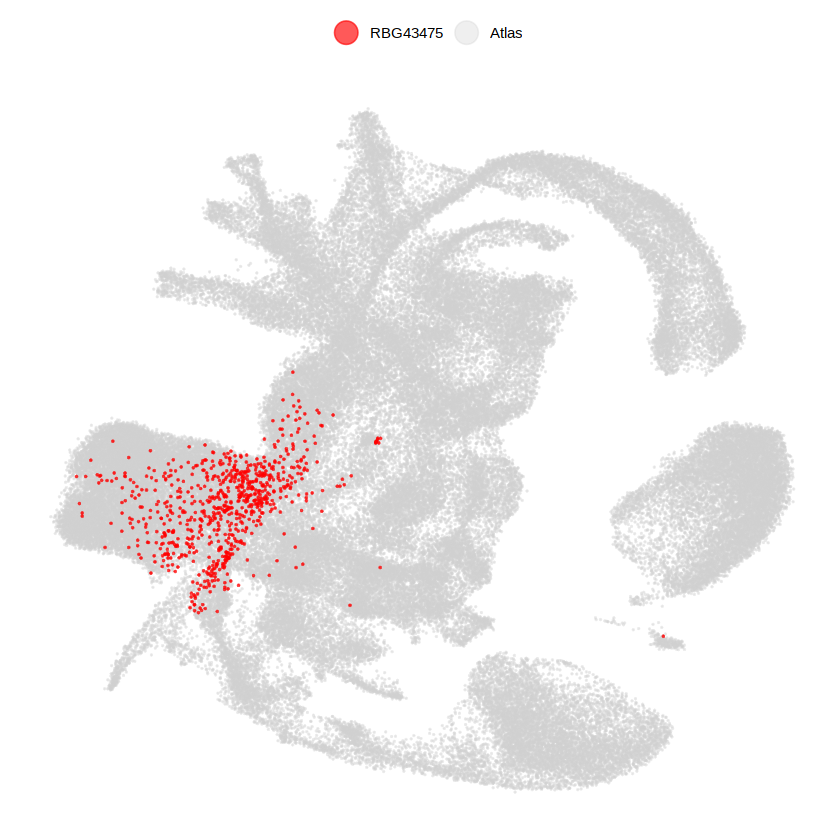

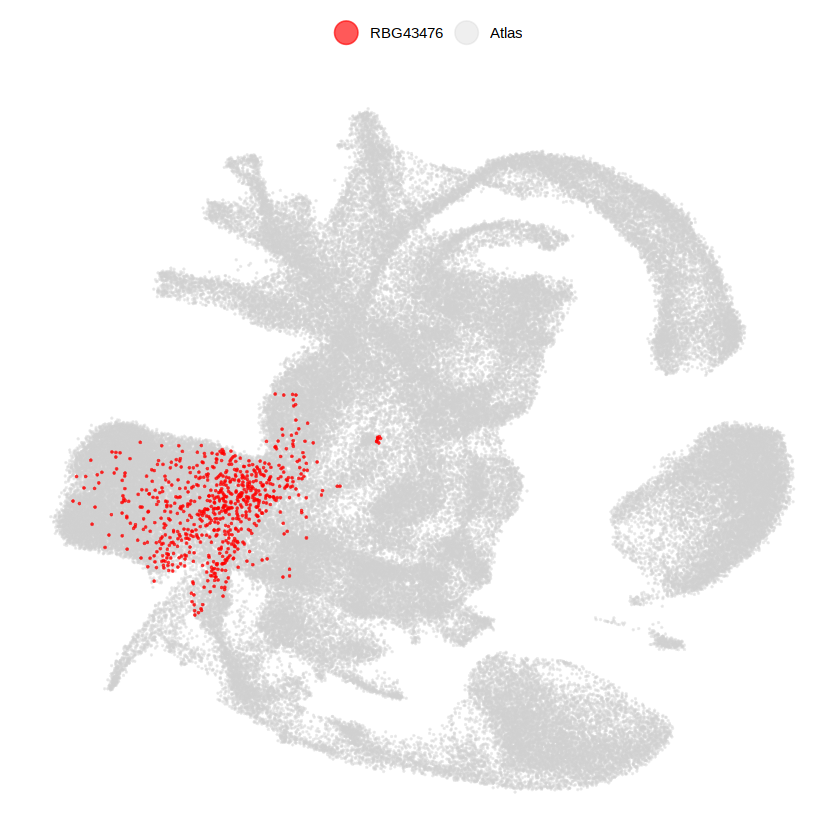

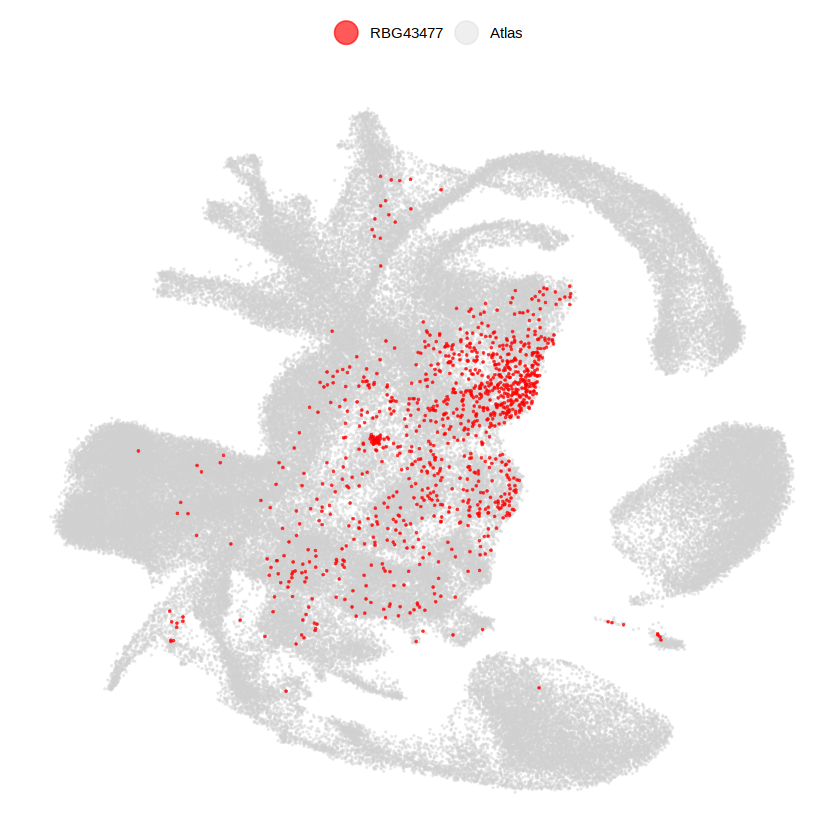

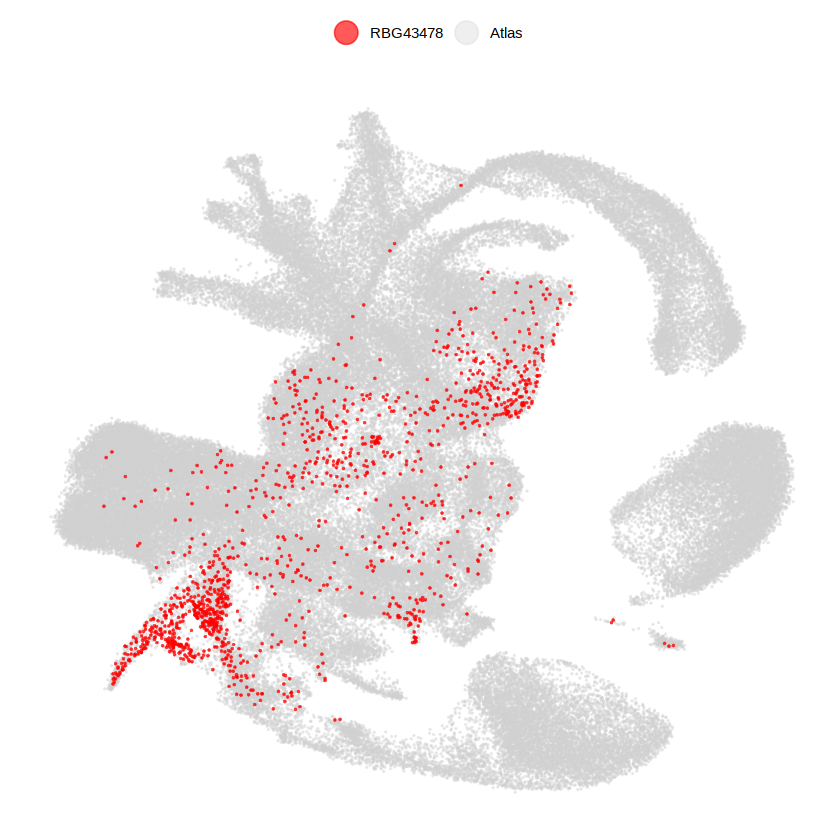

In [5]:

####################
## Plot all cells ##
####################

to.plot <- umap.dt %>% copy %>%
  .[,index:=match(cell, sample_metadata[,closest.cell] )] %>% 
  .[,mapped:=as.factor(!is.na(index))] %>% 
  .[,mapped:=plyr::mapvalues(mapped, from = c("FALSE","TRUE"), to = c("scRNA-seq atlas","Experiment"))] %>%
  setorder(mapped) 

p <- plot.dimred(to.plot, query.label = "Experiment", atlas.label = "scRNA-seq atlas")

# pdf(sprintf("%s/umap_mapped_allcells.pdf",args$outdir), width=8, height=6.5)
 print(p)
# dev.off()

to.plot <- umap.dt %>% copy %>%
  .[,index:=match(cell, sample_metadata[,closest.cell] )] %>% 
  .[,mapped:=as.factor(!is.na(index))] %>% 
  .[,mapped:=plyr::mapvalues(mapped, from = c("FALSE","TRUE"), to = c("scRNA-seq atlas","Experiment"))] %>%
  setorder(mapped) 

p <- plot.dimred(to.plot, query.label = "Experiment", atlas.label = "scRNA-seq atlas")

# pdf(sprintf("%s/umap_mapped_allcells.pdf",args$outdir), width=8, height=6.5)
 print(p)
# dev.off()

###############################
## Plot one sample at a time ##
###############################

for (i in args$samples) {
  
  to.plot <- umap.dt %>% copy %>%
    .[,index:=match(cell, sample_metadata[sample==i,closest.cell] )] %>% 
    .[,mapped:=as.factor(!is.na(index))] %>% 
    .[,mapped:=plyr::mapvalues(mapped, from = c("FALSE","TRUE"), to = c("Atlas",i))] %>%
    setorder(mapped) 
  
  p <- plot.dimred(to.plot, query.label = i, atlas.label = "Atlas")
  
#  pdf(sprintf("%s/umap_mapped_%s.pdf",args$outdir,i), width=8, height=6.5)
  print(p)
 # dev.off()
}
